In [1]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_A_OCTOBER_FINAL.csv to MACHINE_A_OCTOBER_FINAL.csv


,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Categories,Price
0,Master,Machine A,31-10-25 20:34,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard
1,Master,Machine A,31-10-25 20:16,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard
2,Master,Machine A,31-10-25 19:42,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable
3,Master,Machine A,31-10-25 19:40,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,31-10-25 19:40,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard


In [4]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Categories",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price
0,Master,Machine A,31-10-25 20:34,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard
1,Master,Machine A,31-10-25 20:16,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard
2,Master,Machine A,31-10-25 19:42,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable
3,Master,Machine A,31-10-25 19:40,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,31-10-25 19:40,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard


In [5]:
# Feature Engineering
import pandas as pd

# Parse the date correctly (DD-MM-YY HH:MM)
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%d-%m-%y %H:%M")

# Extract useful time features
df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()



,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine A,2025-10-31 20:34:00,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
1,Master,Machine A,2025-10-31 20:16:00,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
2,Master,Machine A,2025-10-31 19:42:00,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable,19,31,4
3,Master,Machine A,2025-10-31 19:40:00,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard,19,31,4
4,Master,Machine A,2025-10-31 19:40:00,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard,19,31,4


In [6]:
# Defining Target & Features
target = "ProductCode"

X = df.drop(["ProductCode", "ProductName", "TransactionDate"], axis=1)
y = df[target]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine A,2025-10-31 20:34:00,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
1,Master,Machine A,2025-10-31 20:16:00,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
2,Master,Machine A,2025-10-31 19:42:00,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable,19,31,4
3,Master,Machine A,2025-10-31 19:40:00,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard,19,31,4
4,Master,Machine A,2025-10-31 19:40:00,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard,19,31,4


In [7]:
# Defining Target & Features
target = "ProductCode"

X = df.drop(["ProductCode", "ProductName", "TransactionDate"], axis=1)
y = df[target]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine A,2025-10-31 20:34:00,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
1,Master,Machine A,2025-10-31 20:16:00,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
2,Master,Machine A,2025-10-31 19:42:00,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable,19,31,4
3,Master,Machine A,2025-10-31 19:40:00,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard,19,31,4
4,Master,Machine A,2025-10-31 19:40:00,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard,19,31,4


In [8]:
# Fill all missing values in X
X = X.fillna(0)

X.head()

,GroupName,Machine,TransactionNo,SlotNo,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine A,3216039,31,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
1,Master,Machine A,3215947,21,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
2,Master,Machine A,3215444,17,Cash,Successful,Delivery,Gluten-free,Affordable,19,31,4
3,Master,Machine A,3215387,11,Cash,Successful,Delivery,Non vegetarian,Standard,19,31,4
4,Master,Machine A,3215231,61,Cash,Successful,Delivery,Vegetarian,Standard,19,31,4


In [9]:
# Updating Values for X
X = X.fillna(0)

X.head()

,GroupName,Machine,TransactionNo,SlotNo,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine A,3216039,31,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
1,Master,Machine A,3215947,21,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
2,Master,Machine A,3215444,17,Cash,Successful,Delivery,Gluten-free,Affordable,19,31,4
3,Master,Machine A,3215387,11,Cash,Successful,Delivery,Non vegetarian,Standard,19,31,4
4,Master,Machine A,3215231,61,Cash,Successful,Delivery,Vegetarian,Standard,19,31,4


In [10]:
# Updating Values for Y
y = y.fillna("Unknown")

y.head()

,ProductCode
0,UMMIS3
1,UMMIS17
2,UMMIF1
3,UMMIV10
4,UMMIS7


In [11]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,GroupName,Machine,TransactionNo,SlotNo,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
18,Master,Machine A,3192417,9,Cash,Successful,Delivery,Beverage,Affordable,18,30,3
203,Master,Machine A,2898447,10,Cash,Successful,Delivery,Vegetarian,Affordable,12,20,0
351,Master,Machine A,2695408,9,Cash,Successful,Delivery,Beverage,Affordable,16,9,3
275,Master,Machine A,2797234,41,Cash,Successful,Delivery,Non vegetarian,Standard,17,14,1
63,Master,Machine A,3109305,27,Cash,Successful,Delivery,Non vegetarian,Premium,15,28,1


In [12]:
# Encoding all categorical columns
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Encode categorical columns in X
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = encoder.fit_transform(X[col].astype(str))

# Encode y (ProductCode)
y = LabelEncoder().fit_transform(y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Creating Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

model

RandomForestClassifier(n_estimators=300, random_state=42)

In [15]:
# Prediction
preds = model.predict(X_test)

In [16]:
# Predicting next product likely to be sold
import pandas as pd

# Load datasets
df = pd.read_csv("MACHINE_A_OCTOBER_FINAL.csv")

# Standardize column names if needed
df.columns = df.columns.str.strip()

# Combine both months
df = pd.concat([df], ignore_index=True)

# Count product frequency
product_counts = df['Product Code'].value_counts()

# Most likely next product
next_product_code = product_counts.idxmax()
next_product_name = df[df['Product Code'] == next_product_code].iloc[0]['Menu'] \
                    if 'Menu' in df.columns else df[df['Product Code'] == next_product_code].iloc[0]['Product Name']

print("Most likely next product:", next_product_name, "(", next_product_code, ")")


Most likely next product: Steamed Rice with Butter Chicken  ( UMMIR27 )


In [17]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", accuracy)

Accuracy: 0.8518518518518519


In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
cm

array([[2, 0, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 2]])

In [19]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       0.00      0.00      0.00         1
          13       0.50      1.00      0.67         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         7
          17       1.00      1.00      1.00         5
          18       1.00      1.00      1.00         1
          19       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

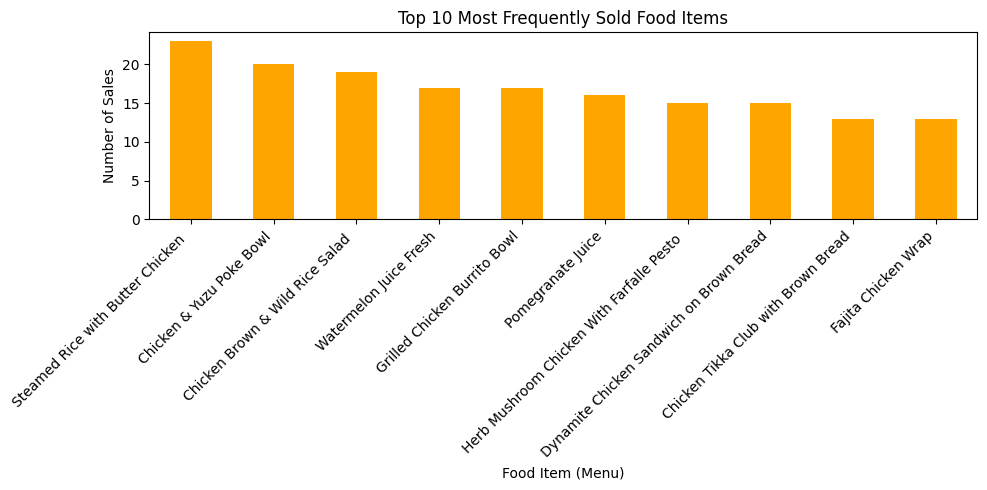

In [20]:
# Food Item Frequency Bar Chart
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Count frequency of each food item
food_counts = df['Menu'].value_counts().head(10)

plt.figure(figsize=(10,5))
food_counts.plot(kind='bar', color='orange')

plt.title("Top 10 Most Frequently Sold Food Items")
plt.xlabel("Food Item (Menu)")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

/tmp/ipykernel_498/2810516242.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')


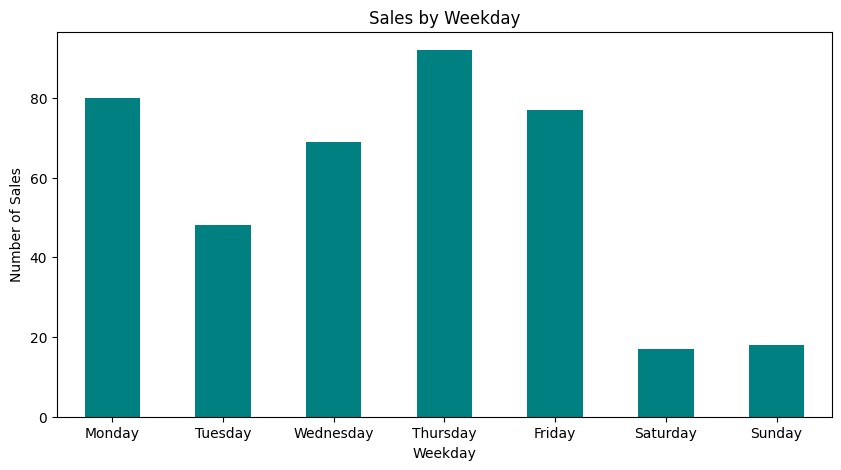

In [23]:
# Sales By Weekday
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# Count weekday frequency
weekday_counts = df['Transaction Date'].dt.weekday.value_counts().sort_index()

# Map numbers to weekday names
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,5))
weekday_counts.plot(kind='bar', color='teal')

plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Sales")
plt.xticks(ticks=range(7), labels=weekday_labels, rotation=0)
plt.show()

